## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Team List and Credits:
- Ricardo Aguiar Bomeny: 
- Thiago Donato: 
- Darren Rauvola: Analysis, Conceptualization, Experimental investigation, Writing - original draft 
- Kiame McCartha: Hypothesis
- Dmitri Singer: 

# Research Question

Out of these three categories of features: temporal features (hour, day of week, holidays), spatial features (pickup zone), and weather conditions (temperature, precipitation, snowfall) which one feature or combination of features is most important in forecasting taxi demand (number of rides per time interval - daily or hourly) in New York City?

## Background and Prior Work


Taxi services are a key part of NYC's urban lifestyle. The iconic yellow cabs completed over 200 million trips annually before the pandemic <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). Surprisingly, we found out that the NYC Taxi and Limousine Commission (TLC) documents their trips extensively since 2009. This makes it into one of the largest and most thorough urban mobility datasets in the world. The data includes features like pickup and dropoff locations, timestamps, fare information, payment type, and passenger counts for every metered taxi ride. We were blown away when we saw this! There were almost infinite questions we could ask or investigate. We thought of predicting taxi demand because it is a key component for companies that want to optimize fleet allocation, drivers who want to be in high-demand areas, and city planners so they can manage transportation policy based on demand.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

Previous research has shown that taxi demand follows predictable spatiotemporal patterns. Moreira-Matias et al. (2013) investigated how time-series forecasting methods work for capturing hourly and daily demand cycles. They found that temporal features such as hour of day and day of week were one of the strongest predictors of taxi pickups <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3).

Besides this, inspired by recent extreme weather in NYC, we thought about investigating whether weather conditions impact taxi ridership patterns. Singhal et al. (2014) did a comprehensive analysis of weather effects on NYC rides and found that precipitation has a statistically significant positive effect on taxi demand (as rain increases, more people choose taxis over walking or waiting for buses) <a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4). The same was true for extreme heat.

Our project builds on this prior work by developing an integrated prediction model that combines temporal features (hour, day of week, month), spatial features (pickup zone), and weather conditions (temperature, precipitation) to forecast taxi demand + fare distribution. While previous studies have looked at these features separately, we'll try to quantify their relative importance using feature importance analysis and compare the predictive performance of multiple machine learning models including Linear Regression, Random Forest, and maybe even neural networks. 

Using recent TLC trip data and NOAA weather observations from Central Park, we will evaluate whether the patterns identified in earlier research hold in contemporary data and identify which factors most strongly drive taxi demand in New York City.

Citations:
1. <a name="cite_note-1"></a> [^](#cite_ref-1) NYC Taxi and Limousine Commission. (2024). TLC Trip Record Data. https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

2. <a name="cite_note-2"></a> [^](#cite_ref-2) Correa, D. & Moyano, C. (2023). Analysis and prediction of New York City taxi and Uber demands. Journal of Applied Research and Technology, 21(5), 886-898.

3. <a name="cite_note-3"></a> [^](#cite_ref-3) Moreira-Matias, L., Gama, J., Ferreira, M., Mendes-Moreira, J., & Damas, L. (2013). Predicting taxi-passenger demand using streaming data. IEEE Transactions on Intelligent Transportation Systems, 14(3), 1393-1402.

4. <a name="cite_note-4"></a> [^](#cite_ref-4) Singhal, A., Kamga, C., & Yazici, A. (2014). Impact of weather on urban transit ridership. Transportation Research Part A: Policy and Practice, 69, 379-391.


# Hypothesis


- Temporal feature relevance: We believe that temporal features like hour of day and holidays will be most correlated with taxi demand because of things like "rush hour" and from our personal experience trying to get a taxi/uber during valentines at dinner time for example is much harder than on non-holiday dates. We don't think day of the week plays a significant role as much as these other temporal features because in a busy city like NY, the variability of the things people do in a given day is too high to be able to claim that there is a special day of the week where demand is higher. We think demand per day will average out to be about the same.
- Spacial feature relevance: We believe that some burrows will have much higher demand than others simply because of the functional role of that burrow (eg. living spaces vs work spaces vs social spaces), with Manhattan (for its social/work areas) being the most busy.
- Weather feature relevance: We think extreme temperatures (<50F and >90F), high precipitations (>10mm/h), and snowfall (any snowfall > 0in) will increase taxi demand. We think these will play a significant role because people generally don't want to walk in these conditions (as mentioned in [4] above).



## Data

### Data overview

We use three datasets that together allow us to model NYC taxi demand as a function of time, location, and weather:

- **Dataset 1 — NYC Yellow Taxi Trip Records (Dec 2024–Feb 2025)**
  - Source: [NYC Taxi & Limousine Commission (TLC)](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
  - Observations: ~11 million trips (3 monthly parquet files)
  - Variables: 20 columns including pickup/dropoff timestamps, location zone IDs, passenger count, trip distance, fare amount, and surcharges
  - Key variables: `tpep_pickup_datetime`, `PULocationID`, `passenger_count`, `trip_distance`, `fare_amount`, `total_amount`
  - Shortcomings: ~25% of rows have null `passenger_count`. Some trips have dates outside the expected month. No rider demographics.

- **Dataset 2 — NOAA Daily Weather Summaries (Dec 2024–Feb 2025)**
  - Source: [NOAA Climate Data Online](https://www.ncdc.noaa.gov/cdo-web/) — Station USW00094728 (Central Park, NYC)
  - Observations: 90 daily records
  - Variables: 6 columns — `date`, `temp_max_f`, `temp_min_f`, `precipitation_in`, `snowfall_in`, `snow_on_ground_in`
  - Parsed from official NOAA PDF reports.
  - Shortcomings: Single weather station for all of NYC; actual weather may be different in other boroughs.

- **Dataset 3 — NYC Taxi Zone Lookup**
  - Source: [NYC TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
  - Observations: 265 zones
  - Variables: `LocationID`, `Borough`, `Zone`, `service_zone`
  - Maps numeric zone IDs in the trip data to human-readable borough and zone names.

**Combining the datasets:** Taxi trips are joined to the zone lookup on `PULocationID = LocationID` to add borough/zone names. A `date` column extracted from pickup timestamps joins trips with daily weather. The final merged dataset has one row per trip with added borough/zone names and that day's weather conditions.

In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
%pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?id=1uqW6HLQWbky5cZA_OmJGp1VRdFCcWrSY', 'filename': 'yellow_tripdata_2024-12.parquet' },
    { 'url': 'https://drive.google.com/uc?id=1TdzWDei4EQNvA192MRh9ViAAGd9Om_hp', 'filename': 'yellow_tripdata_2025-01.parquet' },
    { 'url': 'https://drive.google.com/uc?id=1Csr-9K8WW4kjpdo3ile8dcnk4NsIJ9ic', 'filename': 'yellow_tripdata_2025-02.parquet' },
    { 'url': 'https://drive.google.com/uc?id=1n2nCwsrrD-z_K12KgGtPBmtzQQ4uvTUS', 'filename': 'weather.csv' },
    { 'url': 'https://drive.google.com/uc?id=1EBxlK--zYYWDTyqdPKF903ShGRvu5bjf', 'filename': 'taxi_zone_lookup.csv' },
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Note: you may need to restart the kernel to use updated packages.


Overall Download Progress:  20%|██        | 1/5 [00:05<00:20,  5.17s/it]

Successfully downloaded: yellow_tripdata_2024-12.parquet


Overall Download Progress:  40%|████      | 2/5 [00:10<00:16,  5.41s/it]

Successfully downloaded: yellow_tripdata_2025-01.parquet


...

Successfully downloaded: yellow_tripdata_2025-02.parquet


Overall Download Progress:  80%|████████  | 4/5 [00:18<00:04,  4.17s/it]

Successfully downloaded: weather.csv


Overall Download Progress: 100%|██████████| 5/5 [00:20<00:00,  4.08s/it]

Successfully downloaded: taxi_zone_lookup.csv


### Dataset 1: NYC Yellow Taxi Trip Records (Dec 2024–Feb 2025)

The NYC Taxi and Limousine Commission publishes monthly trip-level records for all yellow taxi rides. Each row is a single metered trip:

- **tpep_pickup_datetime / tpep_dropoff_datetime** — Timestamps recorded by the taximeter, defining when and how long each trip lasted.
- **PULocationID / DOLocationID** — Integer codes (1–265) identifying the taxi zone for pickup and dropoff. These map to the zone lookup table.
- **passenger_count** — Self-reported by the driver; ranges 0–9 but most trips carry 1–2. About 25% of records have this field null (all from VendorID 1), meaning it is missing systematically by vendor, not at random. Could be a red flag for VendorID 1, and maybe best to remove these rows.
- **trip_distance** — Distance in miles from the taximeter. Zero values indicate cancelled trips or meter errors so we need to remove those
- **fare_amount** — Base fare in USD. Negative values occasionally appear from adjustments.
- **total_amount** — Fare + surcharges + tips + tolls. What the rider actually paid.

**Concerns:** Some trips have dates outside the nominal month (e.g., Nov 30 in the December file). Trips with 0 passengers, 0 distance, or negative fares are meter errors or cancellations. LocationIDs 264 and 265 correspond to "Unknown" zones. All of these are filtered during cleaning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw taxi trip files
taxi_files = [
    'data/00-raw/yellow_tripdata_2024-12.parquet',
    'data/00-raw/yellow_tripdata_2025-01.parquet',
    'data/00-raw/yellow_tripdata_2025-02.parquet',
]
# put all months together in one df
taxi_raw = pd.concat([pd.read_parquet(f) for f in taxi_files], ignore_index=True)

print(f"Raw shape: {taxi_raw.shape}")
print(f"\nColumn dtypes:")
print(taxi_raw.dtypes)
print(f"\nNull counts:")
print(taxi_raw.isnull().sum())
print(f"\nDate range: {taxi_raw['tpep_pickup_datetime'].min()} to {taxi_raw['tpep_pickup_datetime'].max()}")

Raw shape: (10721140, 20)

Column dtypes:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

Null counts:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          167337

In [4]:
# check if any columns are null
null_cols = taxi_raw.columns[taxi_raw.isnull().any()]
print("Columns with nulls:", list(null_cols))

# are nulls random or are they all from the same vendor?
print("\nNull passenger_count by VendorID:")
print(taxi_raw.groupby('VendorID')['passenger_count'].apply(lambda x: x.isnull().sum()))
print("\nThis confirms nulls come entirely from VendorID 1 (not missing at random).")

Columns with nulls: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Null passenger_count by VendorID:
VendorID
1     267538
2    1404606
6       1233
7          0
Name: passenger_count, dtype: int64

This confirms nulls come entirely from VendorID 1 (not missing at random).


In [5]:
# cleaning the data into taxi dataframe
taxi = taxi_raw.copy()
n_before = len(taxi)

# filter to Dec 1, 2024 – Feb 28, 2025 only (exclude out of intended sample dates)
taxi = taxi[
    (taxi['tpep_pickup_datetime'] >= '2024-12-01') &
    (taxi['tpep_pickup_datetime'] < '2025-03-01')
]
print(f"After date filter: {len(taxi):,} rows (removed {n_before - len(taxi):,})")

# drop rows with unknown pickup zones (264, 265)
n = len(taxi)
taxi = taxi[~taxi['PULocationID'].isin([264, 265])]
print(f"After removing unknown zones: {len(taxi):,} rows (removed {n - len(taxi):,})")

# removing errnoeus trips with zero or negative fare
n = len(taxi)
taxi = taxi[taxi['fare_amount'] > 0]
print(f"After removing non-positive fares: {len(taxi):,} rows (removed {n - len(taxi):,})")

# remove extreme fare outliers (> $500) - could be errors, sounds sketchy
n = len(taxi)
taxi = taxi[taxi['fare_amount'] <= 500]
print(f"After removing fare outliers (>$500): {len(taxi):,} rows (removed {n - len(taxi):,})")

# remove cancelled/zero-distance trips
n = len(taxi)
taxi = taxi[taxi['trip_distance'] > 0]
print(f"After removing dist=0 trips: {len(taxi):,} rows (removed {n - len(taxi):,})")

# replace null passenger_count with 1 (most common value) - just to have data clean.
# we are not using passenger_count for taxi demand analysis yet, so its okay to fill it so the data is clean
print(f"\nNull passenger_count before fill: {taxi['passenger_count'].isnull().sum():,}")
taxi['passenger_count'] = taxi['passenger_count'].fillna(1.0)

# get temporal features (change names to something more readable)
taxi['date'] = taxi['tpep_pickup_datetime'].dt.date.astype(str)
taxi['hour'] = taxi['tpep_pickup_datetime'].dt.hour
taxi['day_of_week'] = taxi['tpep_pickup_datetime'].dt.day_name()

# keep only columns we might be interested in
keep_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID',
    'fare_amount', 'total_amount', 'date', 'hour', 'day_of_week'
]
taxi = taxi[keep_cols]

print(f"Final taxi shape: {taxi.shape}")
print(f"\nDate range: {taxi['date'].min()} to {taxi['date'].max()}")
print(f"\nRemaining nulls:\n{taxi.isnull().sum()}")

After date filter: 10,721,108 rows (removed 32)
After removing unknown zones: 10,691,219 rows (removed 29,889)
After removing non-positive fares: 10,281,792 rows (removed 409,427)
After removing fare outliers (>$500): 10,281,660 rows (removed 132)
After removing dist=0 trips: 10,057,973 rows (removed 223,687)

Null passenger_count before fill: 1,330,827
Final taxi shape: (10057973, 11)

Date range: 2024-12-01 to 2025-02-28

Remaining nulls:
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
PULocationID             0
DOLocationID             0
fare_amount              0
total_amount             0
date                     0
hour                     0
day_of_week              0
dtype: int64


In [6]:
# summary statistics for our cleaned data
print('Summary statistics for cleaned taxi data:\n')
print(taxi[['passenger_count', 'trip_distance', 'fare_amount', 'total_amount']].describe().round(2))

trips_per_day = taxi.groupby('date').size()
print(f'\nTrips per day: mean={trips_per_day.mean()}, min={trips_per_day.min()}, max={trips_per_day.max()}')

Summary statistics for cleaned taxi data:

       passenger_count  trip_distance  fare_amount  total_amount
count      10057973.00    10057973.00  10057973.00   10057973.00
mean              1.27           5.49        18.81         27.62
std               0.72         503.86        16.58         20.88
min               0.00           0.01         0.01          0.00
25%               1.00           1.01         9.30         16.02
50%               1.00           1.71        13.50         21.00
75%               1.00           3.22        21.20         29.75
max               9.00      328827.63       500.00        615.31

Trips per day: mean=111755.25555555556, min=52112, max=153849


### Dataset 2: NOAA Daily Weather — Central Park (Dec 2024–Feb 2025)

Daily weather summaries from NOAA station USW00094728 (Central Park, Manhattan). This is the standard reference station for NYC weather, recording continuously since 1869.

- **temp_max_f / temp_min_f** — Daily high and low temperatures in degrees Fahrenheit. For Dec 2024–Feb 2025, highs range from the low 40s (late November) to the mid-80s (early September).
- **precipitation_in** — Total liquid precipitation (rain + melted snow) in inches per 24-hour period. Values of 0.001 represent "trace" amounts (originally "T" in the source data).
- **snowfall_in** — New snowfall in inches. Winter months include multiple snow events.
- **snow_on_ground_in** — Snow depth on the ground. Non-zero after snowfall events.

**Concerns:** Central Park is a single station for an entire metro area. Conditions in the outer boroughs or near airports may differ, especially for localized precipitation.

In [7]:
# get the weather data
weather = pd.read_csv('data/00-raw/weather.csv')

print(f"Weather shape: {weather.shape}")
print(f"Date range: {weather['date'].iloc[0]} to {weather['date'].iloc[-1]}")
print(f"\nData types:\n{weather.dtypes}")
print(f"\nNull counts:\n{weather.isnull().sum()}")
print(f"\nDescriptive statistics:")
weather.describe()

Weather shape: (90, 6)
Date range: 2024-12-01 to 2025-02-28

Data types:
date                  object
temp_max_f           float64
temp_min_f           float64
precipitation_in     float64
snowfall_in          float64
snow_on_ground_in    float64
dtype: object

Null counts:
date                 0
temp_max_f           0
temp_min_f           0
precipitation_in     0
snowfall_in          0
snow_on_ground_in    0
dtype: int64

Descriptive statistics:


,temp_max_f,temp_min_f,precipitation_in,snowfall_in,snow_on_ground_in
count,90.000000,90.000000,90.000000,90.000000,90.000000
mean,40.311111,29.311111,0.086067,0.143411,0.362289
std,9.202643,8.603167,0.187261,0.453191,0.702221
min,19.000000,10.000000,0.000000,0.000000,0.000000
25%,34.000000,24.000000,0.000000,0.000000,0.000000
50%,39.000000,29.000000,0.000000,0.000000,0.000000
75%,46.750000,33.000000,0.087500,0.000000,0.001000
max,60.000000,50.000000,0.910000,3.000000,3.100000


In [8]:
# cleaning it
# filling any nulls in snow_on_ground_in with 0
weather['snow_on_ground_in'] = weather['snow_on_ground_in'].fillna(0.0)

# The code below on this cell was partially generated by Claude Opus from the prompt 
# "assume we have weather dataframe with col 'date_parsed' that is pd.datetime
# write code that checks how many missing days there are. We expect to have one
# day for each day in the range 2024-12-01 to 2025-02-28."

# check that there are no gaps on days
weather['date_parsed'] = pd.to_datetime(weather['date'])
expected_days = pd.date_range('2024-12-01', '2025-02-28', freq='D')
missing_days = set(expected_days) - set(weather['date_parsed'])
print(f'Missing days in weather data: {len(missing_days)} (expected 0)')
print(f'Remaining nulls: {weather.isnull().sum().sum()}')

weather = weather.drop(columns=['date_parsed'])
print(f'\nCleaned weather shape: {weather.shape}')

Missing days in weather data: 0 (expected 0)
Remaining nulls: 0

Cleaned weather shape: (90, 6)


### Dataset 3: Taxi Zone Lookup + Merging All Datasets

The zone lookup maps the integer `LocationID` in the trip data to borough and zone names. We join it to the taxi data on `PULocationID` to add `Borough`, `Zone`, and `service_zone`. Then we join weather data on `date` so every trip is enriched with that day's weather.

In [9]:
# get zone data
zones = pd.read_csv('data/00-raw/taxi_zone_lookup.csv')
print(f"Zone lookup shape: {zones.shape}")
print(f"Boroughs: {zones['Borough'].unique()}")
print(f"\nSample:")
zones.head()

Zone lookup shape: (265, 4)
Boroughs: ['EWR' 'Queens' 'Bronx' 'Manhattan' 'Staten Island' 'Brooklyn' 'Unknown'
 nan]

Sample:


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [10]:
# Merge taxi + zone + weather
# join taxi with zone lookup based on PULocationID
merged = taxi.merge(
    zones, left_on='PULocationID', right_on='LocationID', how='left'
).drop(columns=['LocationID'])

print(f"After zone join: {merged.shape}")
print(f"Null Borough (unmatched zones): {merged['Borough'].isnull().sum()}")

# join with weather on date
merged = merged.merge(weather, on='date', how='left')
print(f"After weather join: {merged.shape}")

# final checks and sanity prints
print(f"\nFinal merged dataset: {merged.shape[0]:,} rows x {merged.shape[1]} columns")
print(f"\nColumn list: {list(merged.columns)}")
print(f"\nRemaining nulls:\n{merged.isnull().sum()}")
print(f"\nSample data:")
merged.head()

After zone join: (10057973, 14)
Null Borough (unmatched zones): 0
After weather join: (10057973, 19)

Final merged dataset: 10,057,973 rows x 19 columns

Column list: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'total_amount', 'date', 'hour', 'day_of_week', 'Borough', 'Zone', 'service_zone', 'temp_max_f', 'temp_min_f', 'precipitation_in', 'snowfall_in', 'snow_on_ground_in']

Remaining nulls:
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
PULocationID             0
DOLocationID             0
fare_amount              0
total_amount             0
date                     0
hour                     0
day_of_week              0
Borough                  0
Zone                     0
service_zone             0
temp_max_f               0
temp_min_f               0
precipitation_in         0
snowfall_in              0
snow_on_ground_in        0
dty

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,date,hour,day_of_week,Borough,Zone,service_zone,temp_max_f,temp_min_f,precipitation_in,snowfall_in,snow_on_ground_in
0,2024-12-01 00:12:27,2024-12-01 00:31:12,1.0,9.76,138,33,38.0,51.97,2024-12-01,0,Sunday,Queens,LaGuardia Airport,Airports,38.0,27.0,0.0,0.0,0.0
1,2024-12-01 00:50:35,2024-12-01 01:24:46,4.0,20.07,132,236,70.0,82.69,2024-12-01,0,Sunday,Queens,JFK Airport,Airports,38.0,27.0,0.0,0.0,0.0
2,2024-12-01 00:18:16,2024-12-01 00:33:16,3.0,2.34,142,186,15.6,24.72,2024-12-01,0,Sunday,Manhattan,Lincoln Square East,Yellow Zone,38.0,27.0,0.0,0.0,0.0
3,2024-12-01 00:56:13,2024-12-01 01:18:25,1.0,5.05,107,80,26.8,36.80,2024-12-01,0,Sunday,Manhattan,Gramercy,Yellow Zone,38.0,27.0,0.0,0.0,0.0
4,2024-12-01 00:21:17,2024-12-01 00:37:22,1.0,4.30,249,141,20.5,30.60,2024-12-01,0,Sunday,Manhattan,West Village,Yellow Zone,38.0,27.0,0.0,0.0,0.0


In [11]:
# save changes to processed dir
merged.to_parquet('data/02-processed/taxi_weather_merged.parquet', index=False)
print(f"Saved merged dataset to data/02-processed/taxi_weather_merged.parquet")

# save cleaned individual data to their interim dirs
taxi.to_parquet('data/01-interim/taxi_cleaned.parquet', index=False)
weather.to_csv('data/01-interim/weather_cleaned.csv', index=False)
print(f"Saved cleaned taxi to data/01-interim/taxi_cleaned.parquet")
print(f"Saved cleaned weathe to data/01-interim/weather_cleaned.csv")

Saved merged dataset to data/02-processed/taxi_weather_merged.parquet
Saved cleaned taxi to data/01-interim/taxi_cleaned.parquet
Saved cleaned weathe to data/01-interim/weather_cleaned.csv


## Results

### Exploratory Data Analysis

We split our EDA into three sections following our research question - temporal, spacial, weather feature relevance. You'll find each separate analysis below

PS: Our processed data file was too big to push to github, so unfortunately you will have to run the Data section again to get the data in the right folder



## Temporal Features EDA

### Getting a view of the dataset again

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_parquet("data/02-processed/taxi_weather_merged.parquet")

print(df.shape)
df.head()

(10057973, 19)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,date,hour,day_of_week,Borough,Zone,service_zone,temp_max_f,temp_min_f,precipitation_in,snowfall_in,snow_on_ground_in
0,2024-12-01 00:12:27,2024-12-01 00:31:12,1.0,9.76,138,33,38.0,51.97,2024-12-01,0,Sunday,Queens,LaGuardia Airport,Airports,38.0,27.0,0.0,0.0,0.0
1,2024-12-01 00:50:35,2024-12-01 01:24:46,4.0,20.07,132,236,70.0,82.69,2024-12-01,0,Sunday,Queens,JFK Airport,Airports,38.0,27.0,0.0,0.0,0.0
2,2024-12-01 00:18:16,2024-12-01 00:33:16,3.0,2.34,142,186,15.6,24.72,2024-12-01,0,Sunday,Manhattan,Lincoln Square East,Yellow Zone,38.0,27.0,0.0,0.0,0.0
3,2024-12-01 00:56:13,2024-12-01 01:18:25,1.0,5.05,107,80,26.8,36.80,2024-12-01,0,Sunday,Manhattan,Gramercy,Yellow Zone,38.0,27.0,0.0,0.0,0.0
4,2024-12-01 00:21:17,2024-12-01 00:37:22,1.0,4.30,249,141,20.5,30.60,2024-12-01,0,Sunday,Manhattan,West Village,Yellow Zone,38.0,27.0,0.0,0.0,0.0


Minor data type checks and name cleanups (should probably be in data section), but doesn't hurt doing it now either.

In [34]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_name()
df["date"] = df["tpep_pickup_datetime"].dt.date

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=day_order, ordered=True)

### Investigating total trips for each hour of day. Visual inspection of correlation

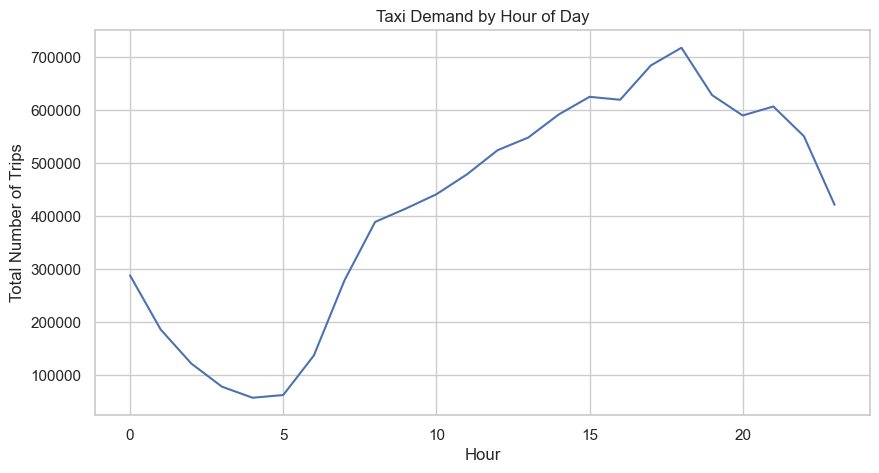

In [35]:
hourly_demand = df.groupby("hour").size()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_demand.index, y=hourly_demand.values)
plt.title("Taxi Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Number of Trips")
plt.show()

This graph displays the total taxi demand by the hour of day. During the later hours of the day, taxi demand increases, likely due to the greater amount of amenities, such as bars and nightclubs, being open at this time of day. Furthermore, the peak is at approx. 17:00 which is during rush hour

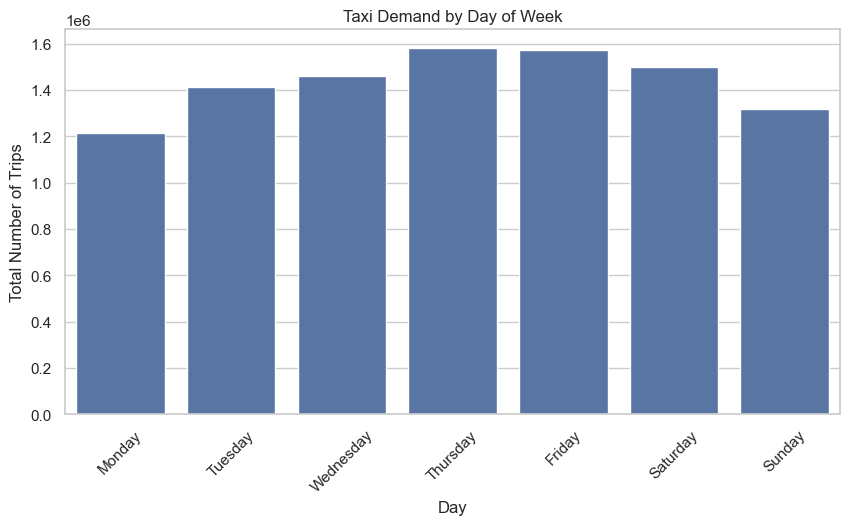

In [36]:
dow_demand = df.groupby("day_of_week",observed=False).size() #observed False because it is already ordered

plt.figure(figsize=(10,5))
sns.barplot(x=dow_demand.index, y=dow_demand.values)
plt.title("Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Number of Trips")
plt.xticks(rotation=45)
plt.show()

Thursday, Friday, and Saturday have the highest amount of taxi demand due to people traveling to and from activities on the weekends. 

We were surprised that Thursday > Friday. Perhaps this is because people are calling in an early weekend and travelling on Thursday, or it might be that less people work in office with the new wave of remote works.

### Holiday investigation

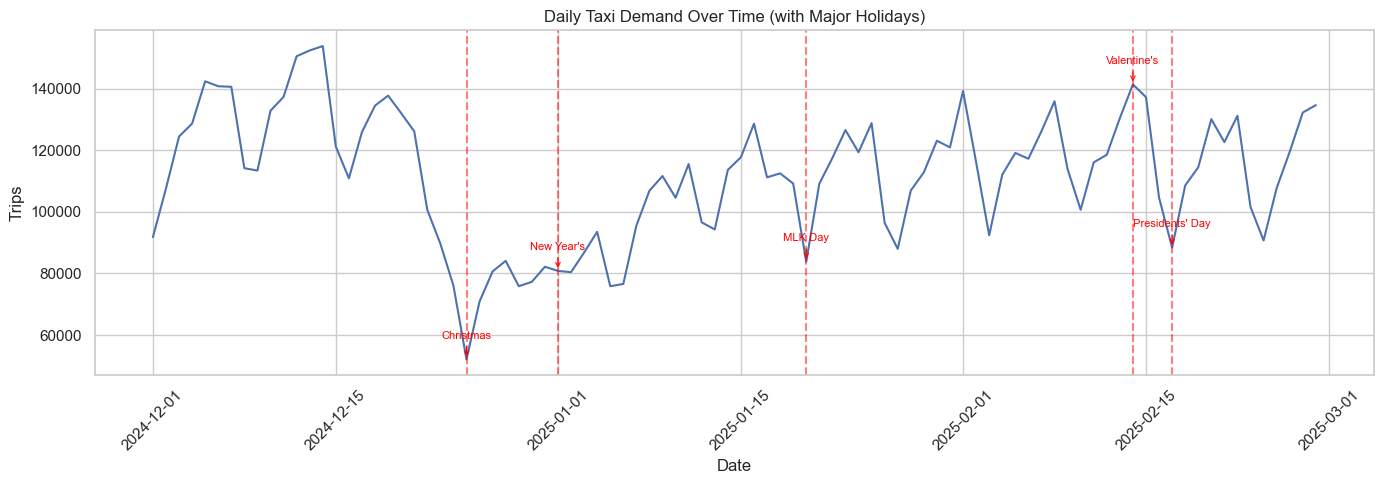

In [37]:
from datetime import date

holidays = {
    date(2024, 12, 25): "Christmas",
    date(2025, 1, 1):   "New Year's",
    date(2025, 1, 20):  "MLK Day",
    date(2025, 2, 14):  "Valentine's",
    date(2025, 2, 17):  "Presidents' Day",
}

daily_demand = df.groupby("date").size()

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(x=daily_demand.index, y=daily_demand.values, ax=ax)

for h_date, label in holidays.items():
    if h_date in daily_demand.index:
        ax.axvline(h_date, color="red", linestyle="--", alpha=0.5)
        ax.annotate(label, xy=(h_date, daily_demand[h_date]),
                    xytext=(0, 15), textcoords="offset points",
                    ha="center", fontsize=8, color="red",
                    arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

ax.set_title("Daily Taxi Demand Over Time (with Major Holidays)")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The taxi demand peaks during typical travel times for the winter holidays, and has a noticable dip during Christmas, MLK Day and President's day when people are at home with their loved ones. Interestingly, New Year's day didn't change much and Valentine's had a peak (probably due to overwhelming amount of people going on dates)

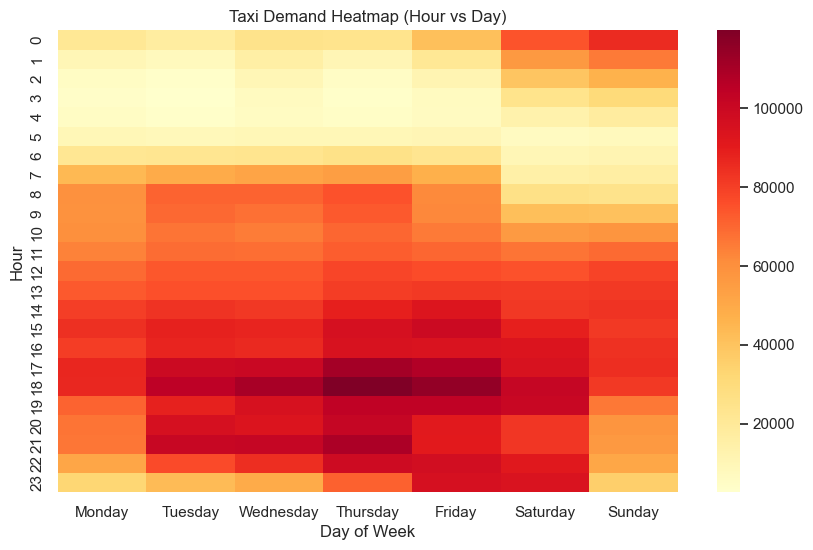

In [38]:
pivot = df.pivot_table(index="hour",columns="day_of_week",values="trip_distance",aggfunc="count",observed=False)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Taxi Demand Heatmap (Hour vs Day)")
plt.xlabel("Day of Week")
plt.ylabel("Hour")
plt.show()

This heatmap shows that most activity occurs at 6pm on Thursday and Friday, likely again coinciding with the rush hour, happy hours and people going to events that are occurring throughout the city.

### Quantifying the predictive power of temporal features

In [39]:
import statsmodels.formula.api as smf
from datetime import date

holiday_dates = {
    date(2024, 12, 25), date(2024, 12, 31),
    date(2025, 1, 1), date(2025, 1, 20),
    date(2025, 2, 14), date(2025, 2, 17),
}

hourly = (
    df.groupby(["date", "hour", "day_of_week"], observed=True)
    .size()
    .reset_index(name="ride_count")
)
hourly["is_holiday"] = hourly["date"].isin(holiday_dates).astype(int)


models = {
    "Hour of Day":    ("C(hour)", smf.ols("ride_count ~ C(hour)", data=hourly).fit()),
    "Day of Week":    ("C(day_of_week)", smf.ols("ride_count ~ C(day_of_week)", data=hourly).fit()),
    "Holiday":        ("C(is_holiday)", smf.ols("ride_count ~ C(is_holiday)", data=hourly).fit()),
    "All Combined":   ("C(hour) + C(day_of_week) + C(is_holiday)", smf.ols("ride_count ~ C(hour) + C(day_of_week) + C(is_holiday)", data=hourly).fit()),
}

for name, (features, m) in models.items():
    print(f"Features: {features}")
    print(f"  {name}  |  R² = {m.rsquared:.4f}  |  Adj. R² = {m.rsquared_adj:.4f}\n")

Features: C(hour)
  Hour of Day  |  R² = 0.7029  |  Adj. R² = 0.6997

Features: C(day_of_week)
  Day of Week  |  R² = 0.0258  |  Adj. R² = 0.0231

Features: C(is_holiday)
  Holiday  |  R² = 0.0089  |  Adj. R² = 0.0084

Features: C(hour) + C(day_of_week) + C(is_holiday)
  All Combined  |  R² = 0.7347  |  Adj. R² = 0.7310



Hour of day is by far the strongest predictor, explaining about 70% of the taxi demand variance. Day of the week and holidays do add some predictive power (about 3%) and perhaps help spot anomaly days (eg. stay at home holiday like Christmas + Friday = much less movement).

It is also no surprise that holiday's are not super predictive because each holiday has its own feature (eg. Valentines increases demand while Christmas decreases it)

## Spatial Features EDA

Loading processed data and aggregating trips by zone and borough.

In [40]:
%pip install geopandas -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

import sys
sys.path.append('./modules')
import spatial_eda as seda

sns.set(context='talk', style='white')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_parquet('data/02-processed/taxi_weather_merged.parquet')
print(f'Loaded merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

zone_demand = seda.aggregate_demand_by_zone(df)
daily_zone_demand = seda.aggregate_daily_demand_by_zone(df)
borough_demand = seda.aggregate_demand_by_borough(df)

print(f'\nZone-level demand: {zone_demand.shape[0]} zones')
print(f'Daily zone demand: {daily_zone_demand.shape[0]:,} zone-day rows')
print(f'Borough demand:\n{borough_demand.to_string(index=False)}')

Note: you may need to restart the kernel to use updated packages.
Loaded merged dataset: 10,057,973 rows x 19 columns
Columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'total_amount', 'date', 'hour', 'day_of_week', 'Borough', 'Zone', 'service_zone', 'temp_max_f', 'temp_min_f', 'precipitation_in', 'snowfall_in', 'snow_on_ground_in']

Zone-level demand: 258 zones
Daily zone demand: 20,795 zone-day rows
Borough demand:
      Borough  total_trips
    Manhattan      8981863
       Queens       841025
     Brooklyn       192027
        Bronx        42174
Staten Island          583
          EWR          301


### Spatial Distribution of Demand

/var/folders/1y/rtyvsjmn7wg8vd5m0dv8zxm00000gn/T/ipykernel_32340/3795603225.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=borough_demand, x='Borough', y='total_trips', order=order,
/var/folders/1y/rtyvsjmn7wg8vd5m0dv8zxm00000gn/T/ipykernel_32340/3795603225.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels([f'{t/1e6:.1f}M' for t in ticks])
/var/folders/1y/rtyvsjmn7wg8vd5m0dv8zxm00000gn/T/ipykernel_32340/3795603225.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, y='label', x='total_trips', palette='YlOrRd_r', ax=axes[1])


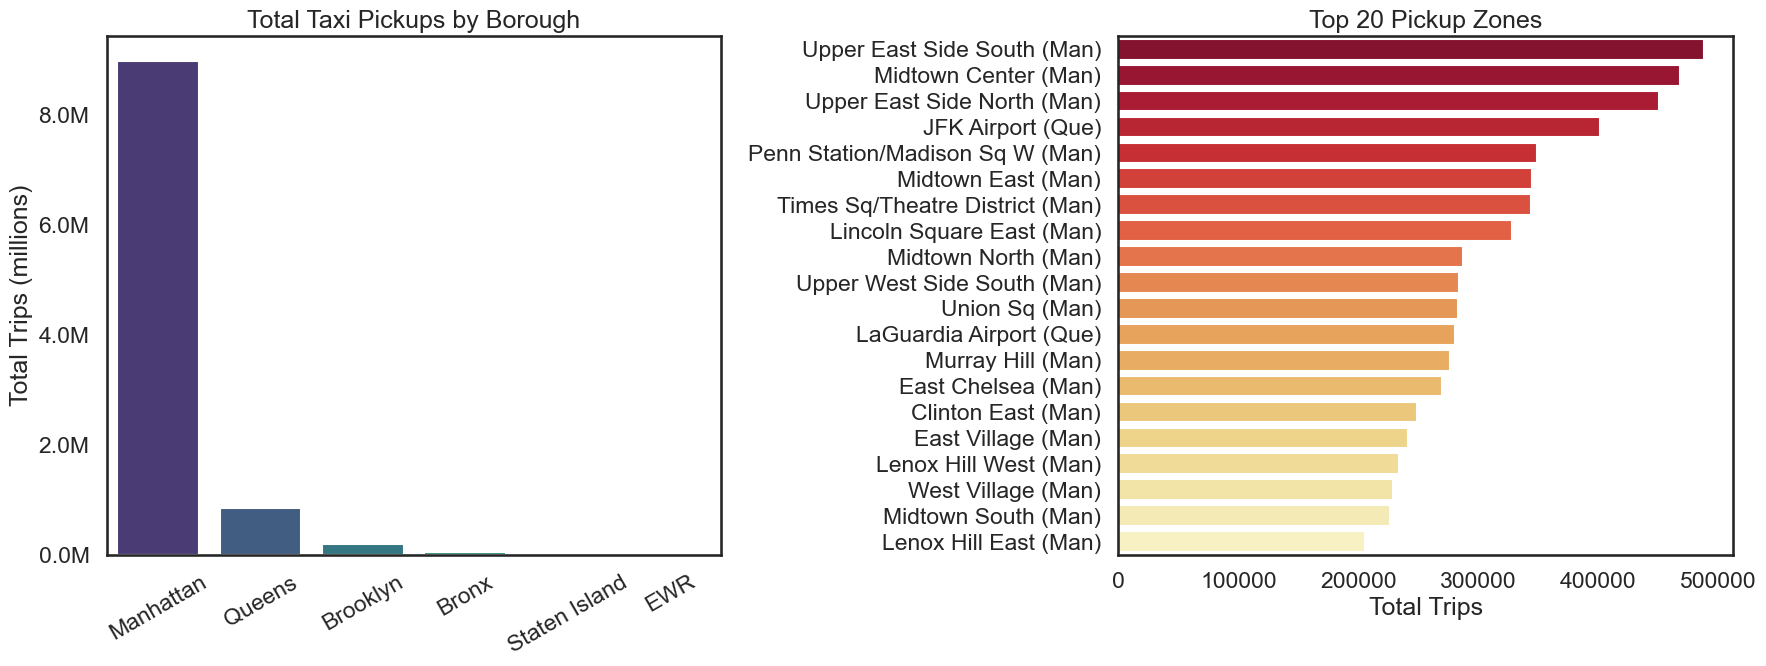

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Borough-level bar chart (left)
order = borough_demand.sort_values('total_trips', ascending=False)['Borough']
sns.barplot(data=borough_demand, x='Borough', y='total_trips', order=order,
            palette='viridis', ax=axes[0])
axes[0].set_title('Total Taxi Pickups by Borough')
axes[0].set_ylabel('Total Trips (millions)')
axes[0].set_xlabel('')
ticks = axes[0].get_yticks()
axes[0].set_yticklabels([f'{t/1e6:.1f}M' for t in ticks])
axes[0].tick_params(axis='x', rotation=30)

# Top 20 zones by demand (right)
top20 = zone_demand.head(20).copy()
top20['label'] = top20['Zone'].str[:25] + ' (' + top20['Borough'].str[:3] + ')'
sns.barplot(data=top20, y='label', x='total_trips', palette='YlOrRd_r', ax=axes[1])
axes[1].set_title('Top 20 Pickup Zones')
axes[1].set_xlabel('Total Trips')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Manhattan dominates taxi demand overwhelmingly — the top 20 zones are almost exclusively in Manhattan, with JFK Airport being the notable exception.

/var/folders/1y/rtyvsjmn7wg8vd5m0dv8zxm00000gn/T/ipykernel_32340/1131821543.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=daily_borough, x='Borough', y='daily_trips', order=borough_order,


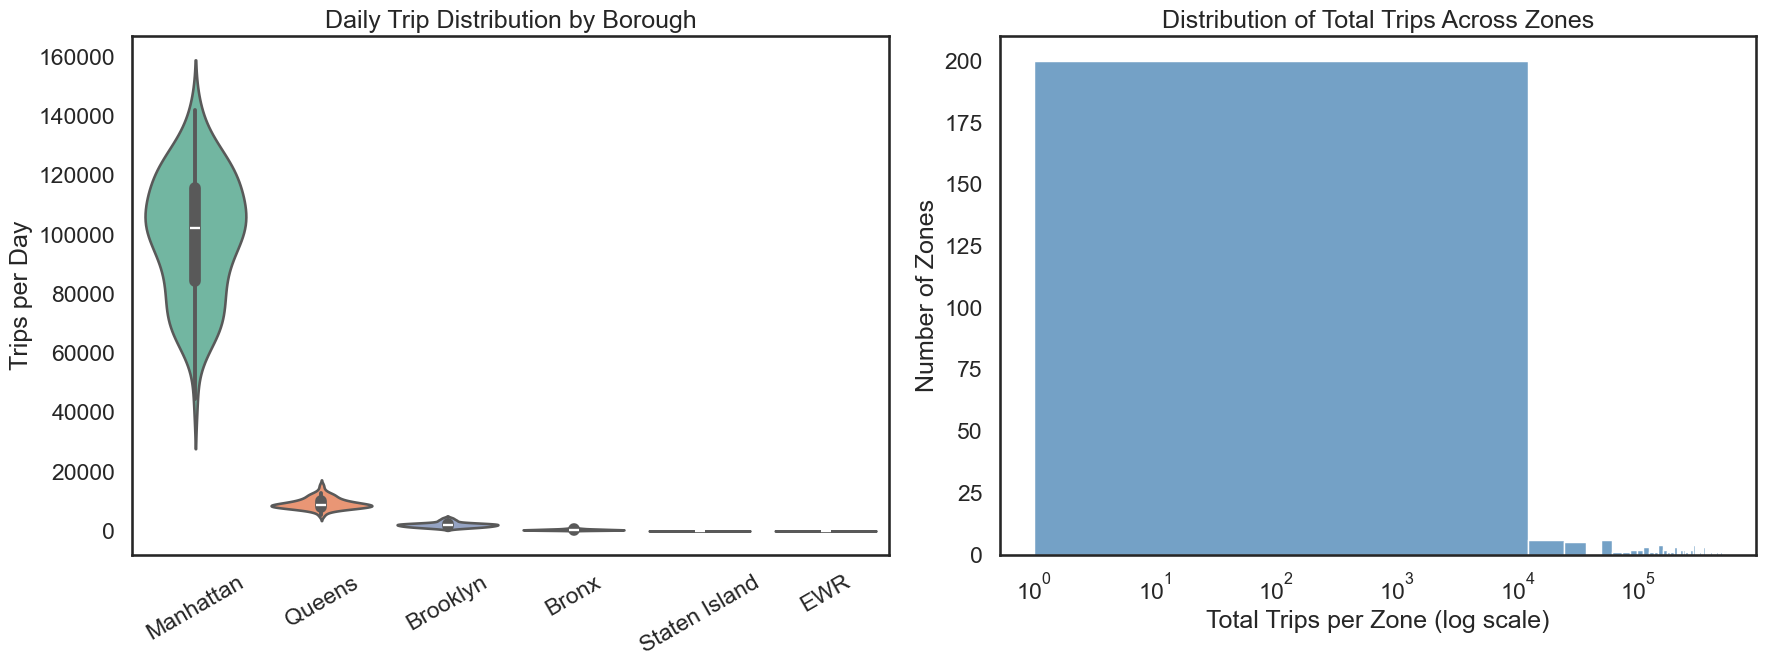

Top 10 zones account for 37.2% of all trips
Top 20 zones account for 62.0% of all trips


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Violin plot of daily demand by borough
daily_borough = daily_zone_demand.groupby(['date', 'Borough'])['daily_trips'].sum().reset_index()
borough_order = daily_borough.groupby('Borough')['daily_trips'].median().sort_values(ascending=False).index
sns.violinplot(data=daily_borough, x='Borough', y='daily_trips', order=borough_order,
               palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('Daily Trip Distribution by Borough')
axes[0].set_ylabel('Trips per Day')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Histogram of zone-level total demand (log scale for readability)
sns.histplot(data=zone_demand, x='total_trips', bins=40, color='steelblue',
             edgecolor='white', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Total Trips Across Zones')
axes[1].set_xlabel('Total Trips per Zone (log scale)')
axes[1].set_ylabel('Number of Zones')

plt.tight_layout()
plt.show()

top10_share = zone_demand.head(10)['total_trips'].sum() / zone_demand['total_trips'].sum() * 100
top20_share = zone_demand.head(20)['total_trips'].sum() / zone_demand['total_trips'].sum() * 100
print(f'Top 10 zones account for {top10_share:.1f}% of all trips')
print(f'Top 20 zones account for {top20_share:.1f}% of all trips')

Manhattan's daily demand is not only higher on average but also more variable day to day than other boroughs. The histogram (log scale) shows a heavily right-skewed distribution. This means a small number of zones generate most of the trips. This power-law-like pattern means that knowing the pickup zone gives us very strong predictive information about demand.

### Choropleth Maps

Using the official NYC taxi zone shapefile, we map pickup demand geographically. We show a raw count map and a log-scaled version to reveal outer-borough patterns.

In [43]:
taxi_zones_gdf = seda.load_taxi_zones_geodata()

geo_demand = taxi_zones_gdf.merge(
    zone_demand, left_on='LocationID', right_on='PULocationID', how='left'
)
geo_demand['total_trips'] = geo_demand['total_trips'].fillna(0)

n_days = df['date'].nunique()
geo_demand['avg_daily_trips'] = geo_demand['total_trips'] / n_days

print(f'Taxi zone shapes: {taxi_zones_gdf.shape[0]}')
print(f'Zones with trip data: {(geo_demand["total_trips"] > 0).sum()}')
print(f'Days in dataset: {n_days}')

Taxi zone shapes: 263
Zones with trip data: 258
Days in dataset: 90


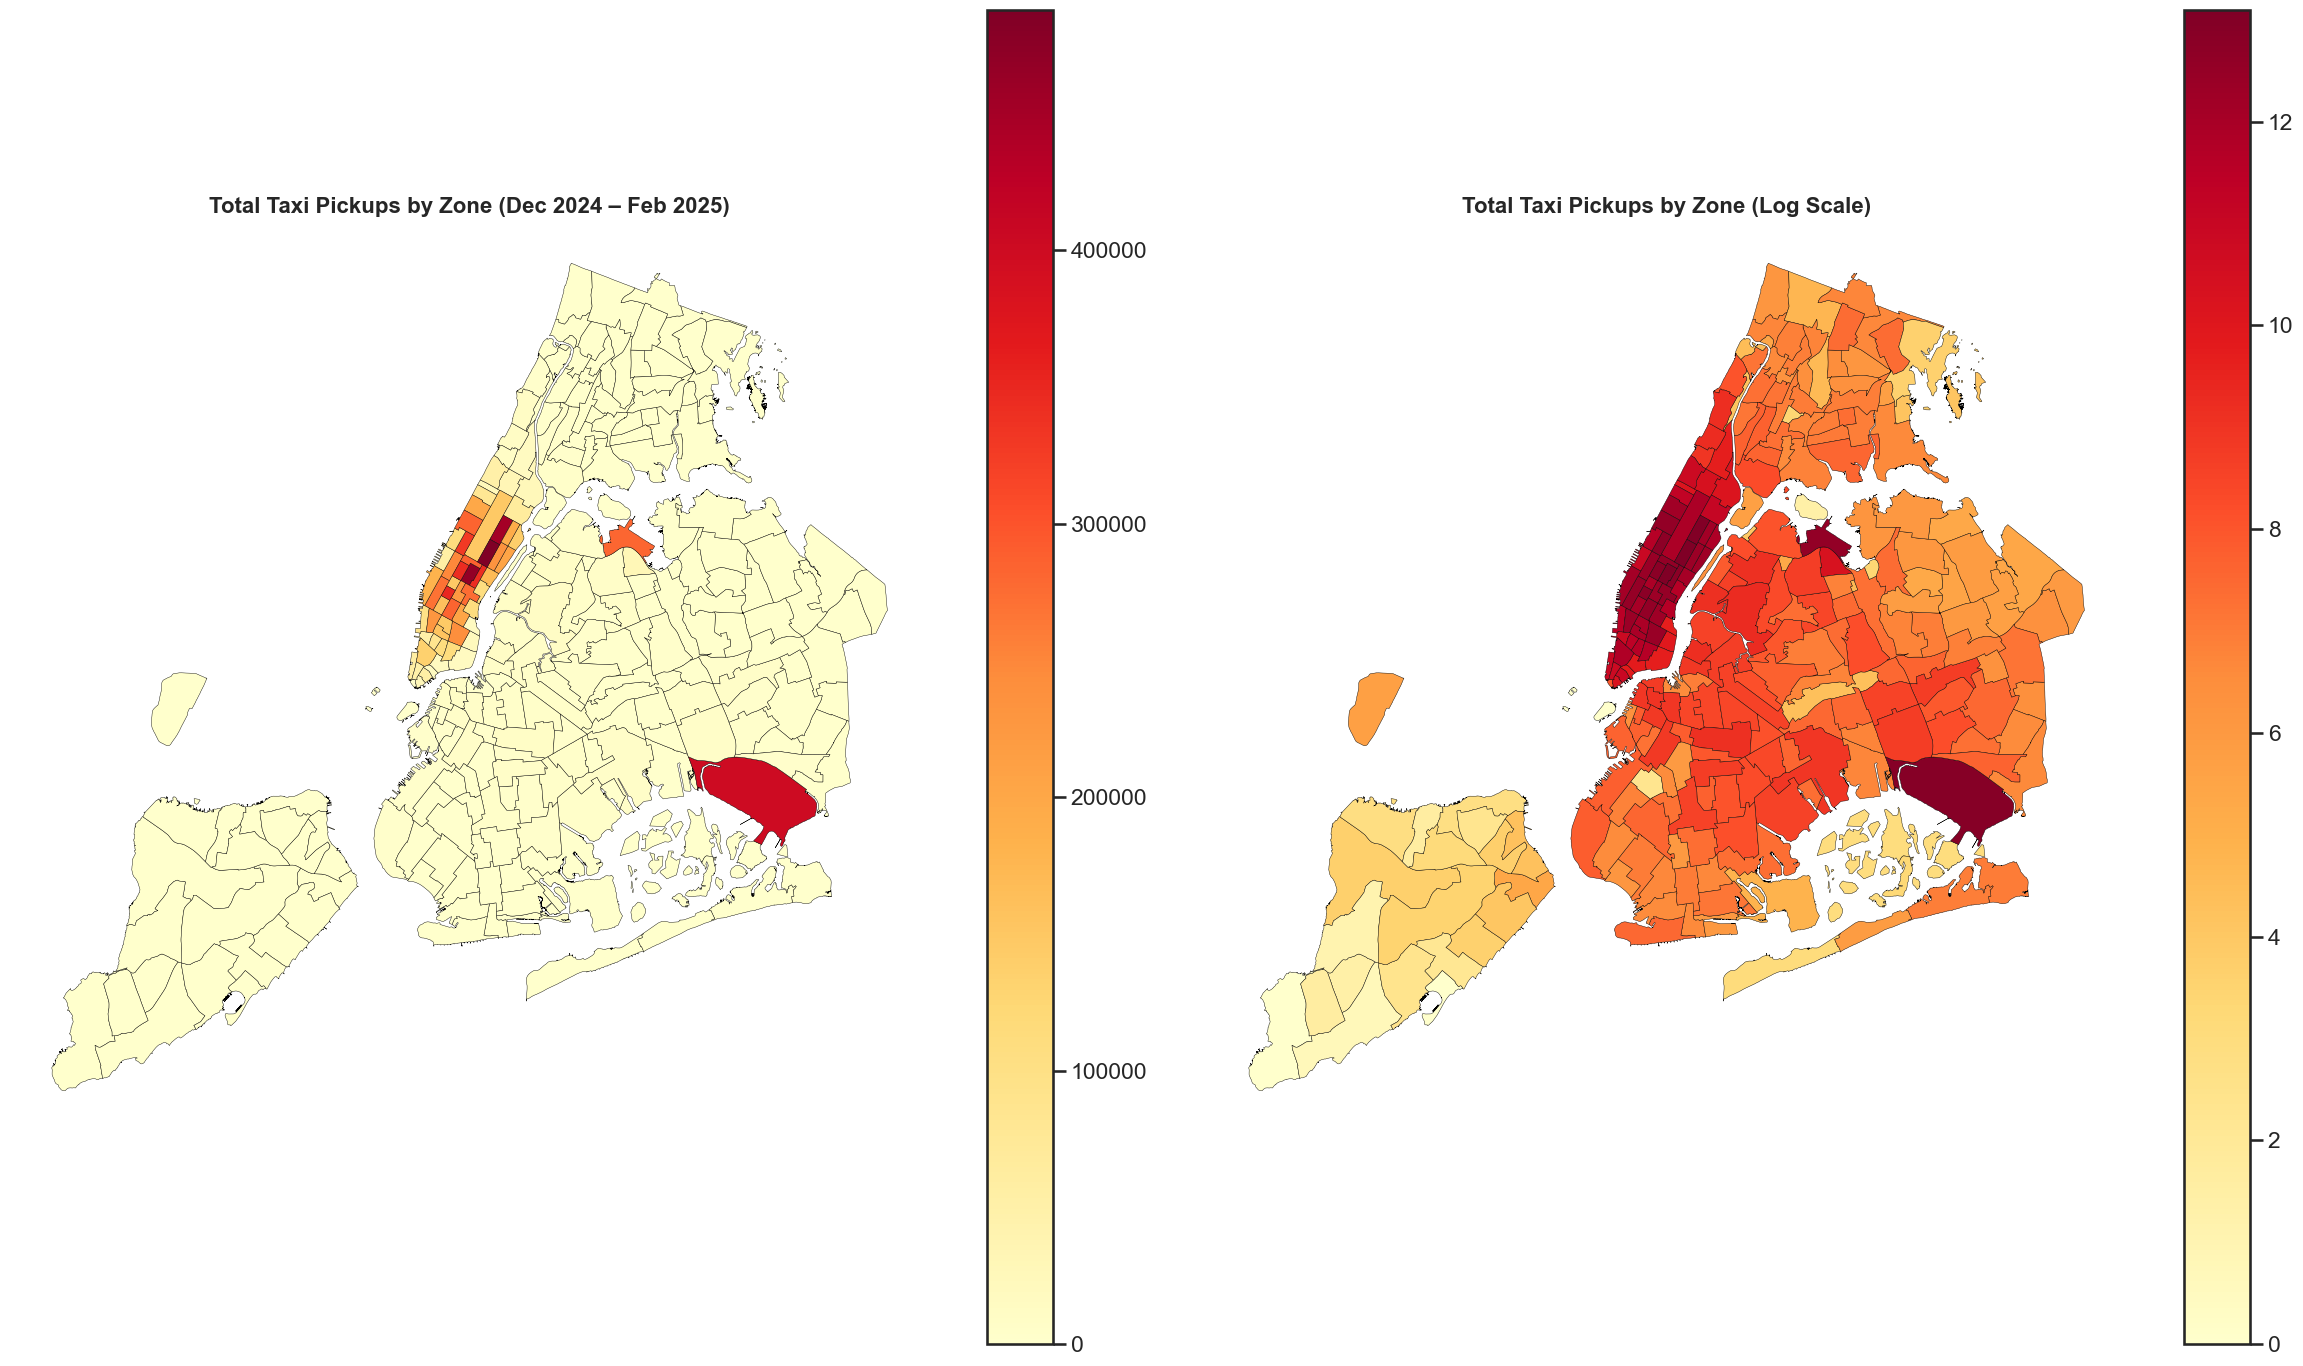

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(24, 14))

seda.plot_choropleth(geo_demand, 'total_trips',
                     'Total Taxi Pickups by Zone (Dec 2024 – Feb 2025)',
                     cmap='YlOrRd', ax=axes[0])

seda.plot_choropleth(geo_demand, 'total_trips',
                     'Total Taxi Pickups by Zone (Log Scale)',
                     cmap='YlOrRd', ax=axes[1], log_scale=True)

plt.tight_layout()
plt.show()

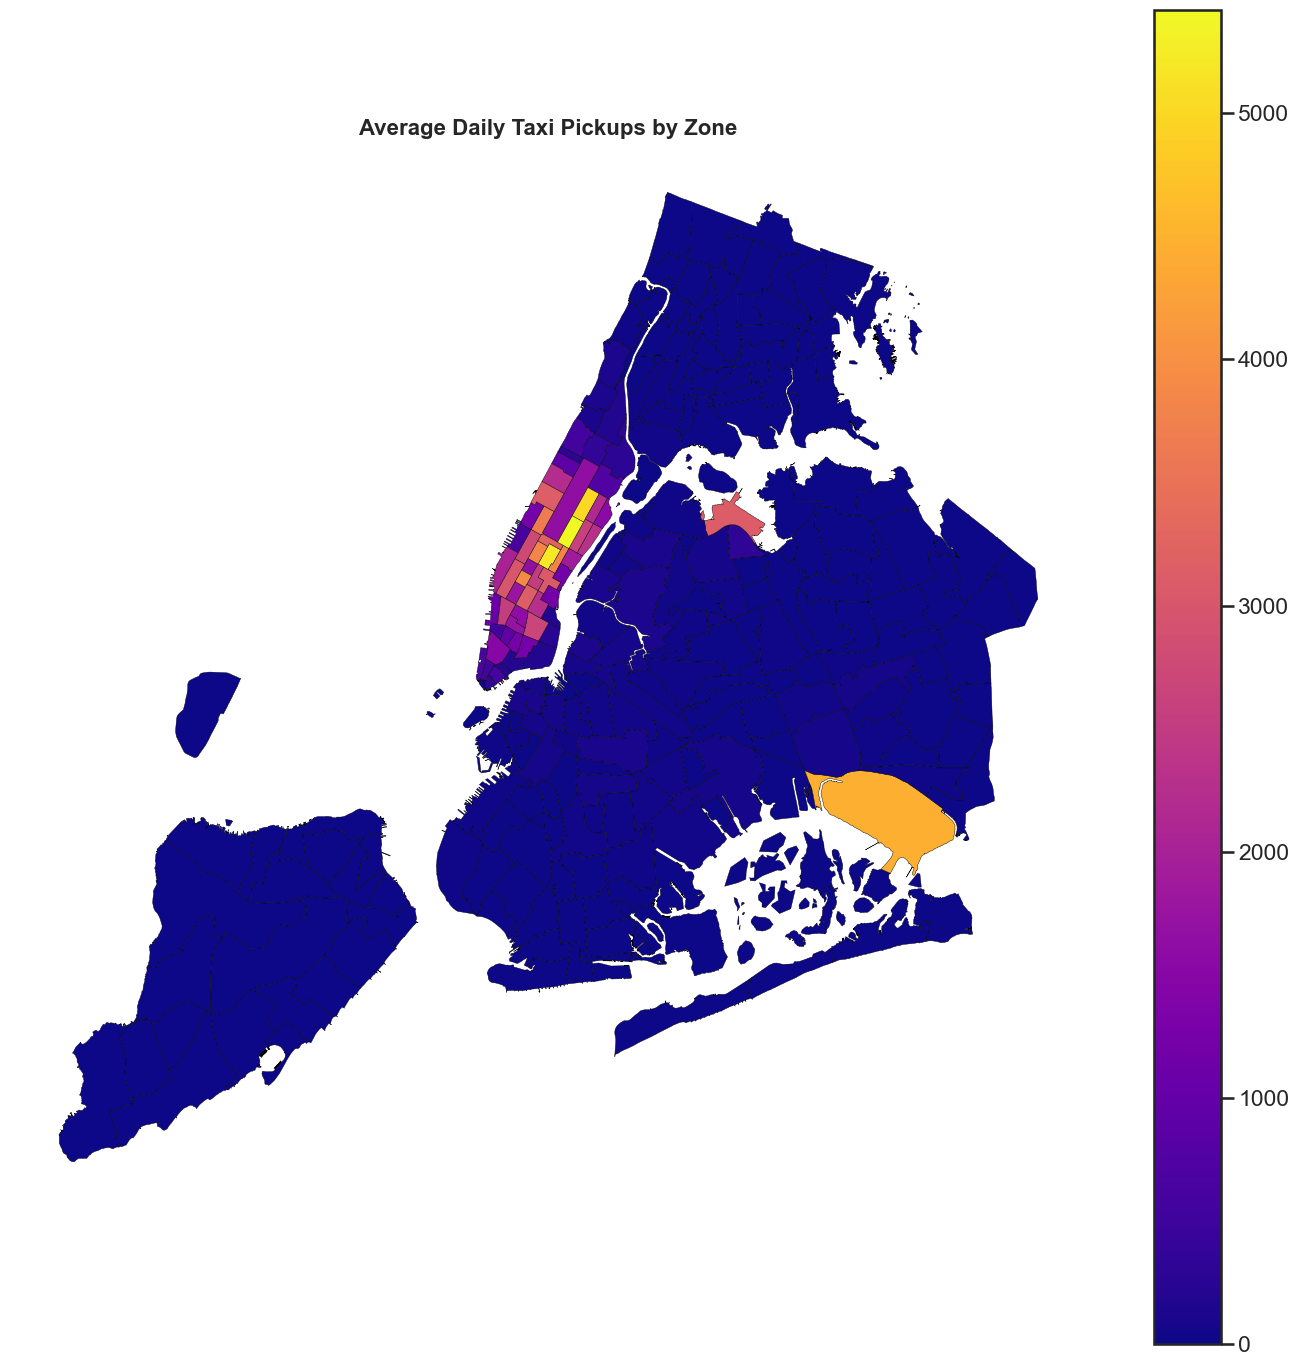

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

seda.plot_choropleth(geo_demand, 'avg_daily_trips',
                     'Average Daily Taxi Pickups by Zone',
                     cmap='plasma', ax=ax)
plt.tight_layout()
plt.show()

The choropleth maps confirm and extend what the bar charts showed:

Midtown and Lower Manhattan dominate the raw count map so heavily that the rest of the city appears uniformly pale. The log-scaled version reveals that airport zones (JFK, LaGuardia) and parts of Brooklyn/Queens have moderate activity, while Staten Island and the Bronx remain very low. The spatial gradient from Manhattan outward is steep.

### Quantifying Spatial Predictive Power

In [46]:
# ANOVA: do boroughs differ significantly in daily zone-level demand?
borough_groups = [
    group['daily_trips'].values
    for _, group in daily_zone_demand.groupby('Borough')
]
f_stat, p_val = stats.f_oneway(*borough_groups)
print(f'One-way ANOVA (Borough): F = {f_stat:.1f}, p = {p_val:.2e}')

# Borough (coarse) vs specific zone (fine-grained)
model_borough = smf.ols('daily_trips ~ C(Borough)', data=daily_zone_demand).fit()
model_zone = smf.ols('daily_trips ~ C(PULocationID)', data=daily_zone_demand).fit()

print(f'\nBorough (5 categories)  R² = {model_borough.rsquared:.4f}')
print(f'Zone (PULocationID)     R² = {model_zone.rsquared:.4f}')
print(f'\nKnowing the specific zone explains {model_zone.rsquared/model_borough.rsquared:.1f}x more variance than borough alone.')

One-way ANOVA (Borough): F = 2328.8, p = 0.00e+00

Borough (5 categories)  R² = 0.3590
Zone (PULocationID)     R² = 0.9155

Knowing the specific zone explains 2.6x more variance than borough alone.


Borough differences are statistically significant (ANOVA p ≈ 0). But the real gain comes from knowing the specific zone; the fine-grained zone model explains substantially more variance than borough alone. This makes sense: a Midtown zone and an Upper East Side zone are both "Manhattan" but have very different demand profiles.

## Weather Features EDA

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# load processed data and aggregate to daily rides
merged = pd.read_parquet('data/02-processed/taxi_weather_merged.parquet')
daily_rides = merged.groupby('date').size().reset_index(name='ride_count')

weather = pd.read_csv('data/01-interim/weather_cleaned.csv')
daily = daily_rides.merge(weather, on='date', how='inner')
daily['date'] = pd.to_datetime(daily['date'])

daily.head()

,date,ride_count,temp_max_f,temp_min_f,precipitation_in,snowfall_in,snow_on_ground_in
0,2024-12-01,91803,38.0,27.0,0.000,0.000,0.0
1,2024-12-02,107584,39.0,29.0,0.000,0.000,0.0
2,2024-12-03,124468,42.0,32.0,0.001,0.001,0.0
3,2024-12-04,128689,42.0,30.0,0.010,0.001,0.0
4,2024-12-05,142417,40.0,31.0,0.090,0.001,0.0


### Plotting distributions of key variables

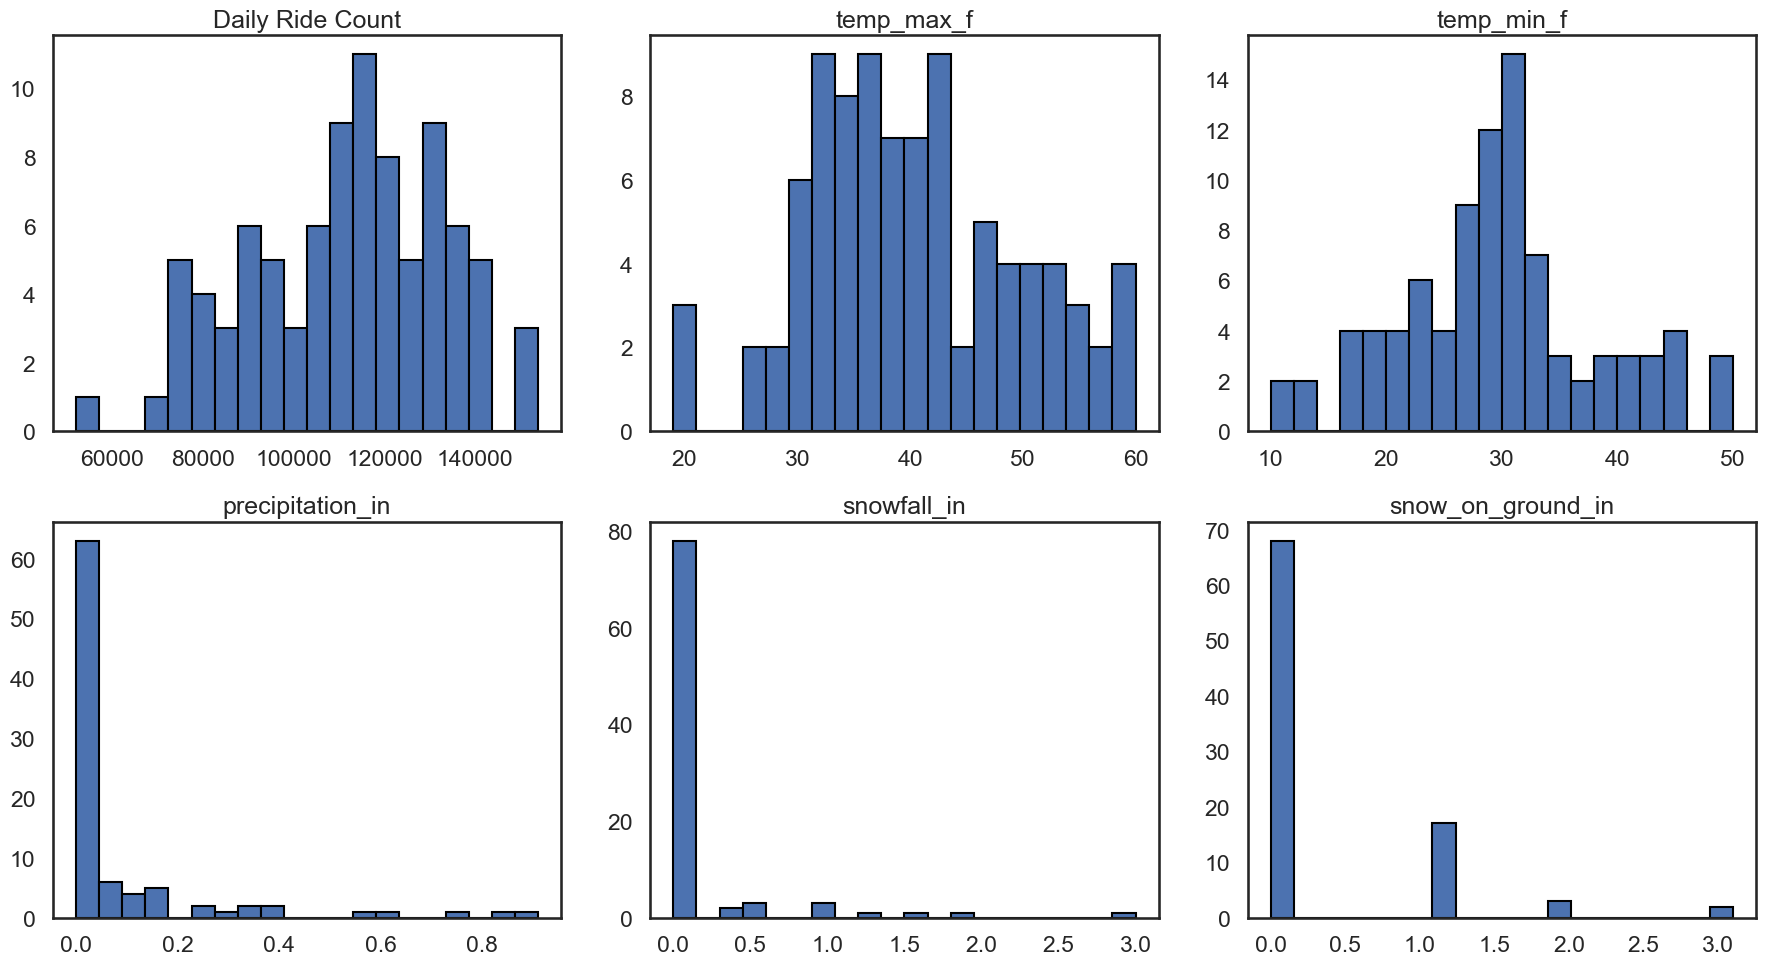

In [48]:
weather_cols = ['temp_max_f', 'temp_min_f', 'precipitation_in', 'snowfall_in', 'snow_on_ground_in']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].hist(daily['ride_count'], bins=20, edgecolor='black')
axes[0, 0].set_title('Daily Ride Count')

for idx, col in enumerate(weather_cols):
    row, c = divmod(idx + 1, 3)
    axes[row, c].hist(daily[col], bins=20, edgecolor='black')
    axes[row, c].set_title(col)

plt.tight_layout()
plt.show()

We can see that `daily ride count`, `temp_max_f`, `temp_min_f` are reasonably normal, but `precipitation`, `snowfall` and `snow_on_ground` are highly skewed which might pose a problem for analysis since they show up in very few of the data points

### Plot across different dates of temperature and precipitation
This is just so we get a visual sense of whether there are any correlations before making any statistical tests.

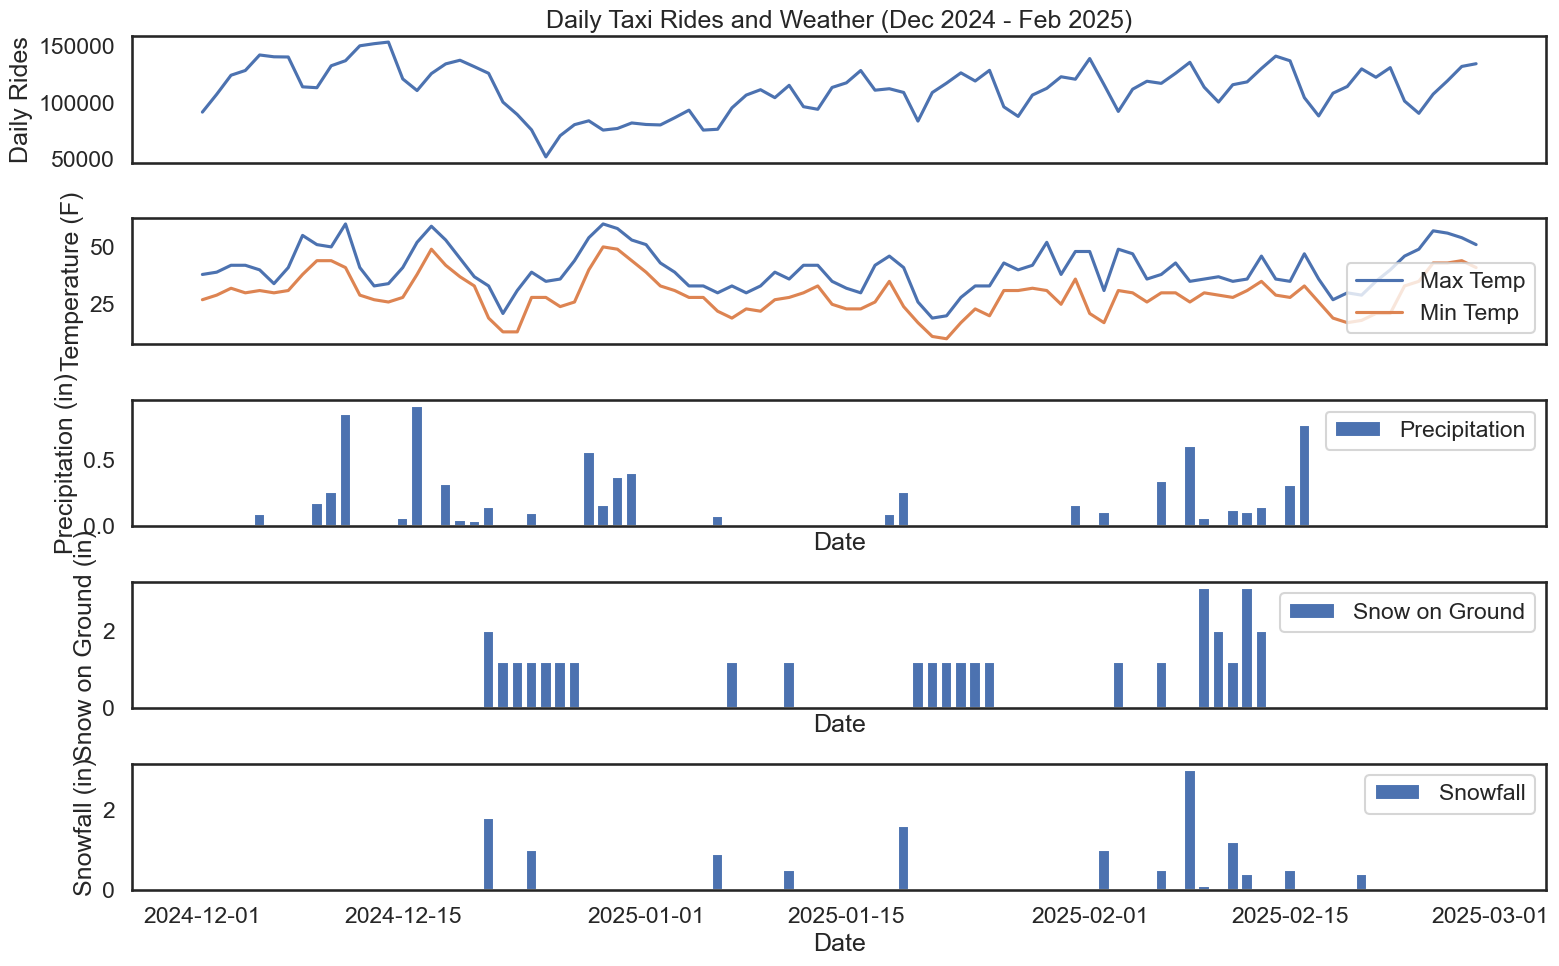

In [49]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10), sharex=True)

axes[0].plot(daily['date'], daily['ride_count'])
axes[0].set_ylabel('Daily Rides')
axes[0].set_title('Daily Taxi Rides and Weather (Dec 2024 - Feb 2025)')

axes[1].plot(daily['date'], daily['temp_max_f'], label='Max Temp')
axes[1].plot(daily['date'], daily['temp_min_f'], label='Min Temp')
axes[1].set_ylabel('Temperature (F)')
axes[1].legend()

axes[2].bar(daily['date'], daily['precipitation_in'], label='Precipitation')
axes[2].set_ylabel('Precipitation (in)')
axes[2].set_xlabel('Date')
axes[2].legend()

axes[3].bar(daily['date'], daily['snow_on_ground_in'], label='Snow on Ground')
axes[3].set_ylabel('Snow on Ground (in)')
axes[3].set_xlabel('Date')
axes[3].legend()

axes[4].bar(daily['date'], daily['snowfall_in'], label='Snowfall')
axes[4].set_ylabel('Snowfall (in)')
axes[4].set_xlabel('Date')
axes[4].legend()

plt.tight_layout()
plt.show()

This again shows how it will be hard to find a correlation between snow/precipitation since these signals/features are rarer in our dataset. Just by inspection, it doesn't seem like the peaks/downs are too related. We'll quantify this feeling more below

### Quantifying how related weather features are to taxi demand

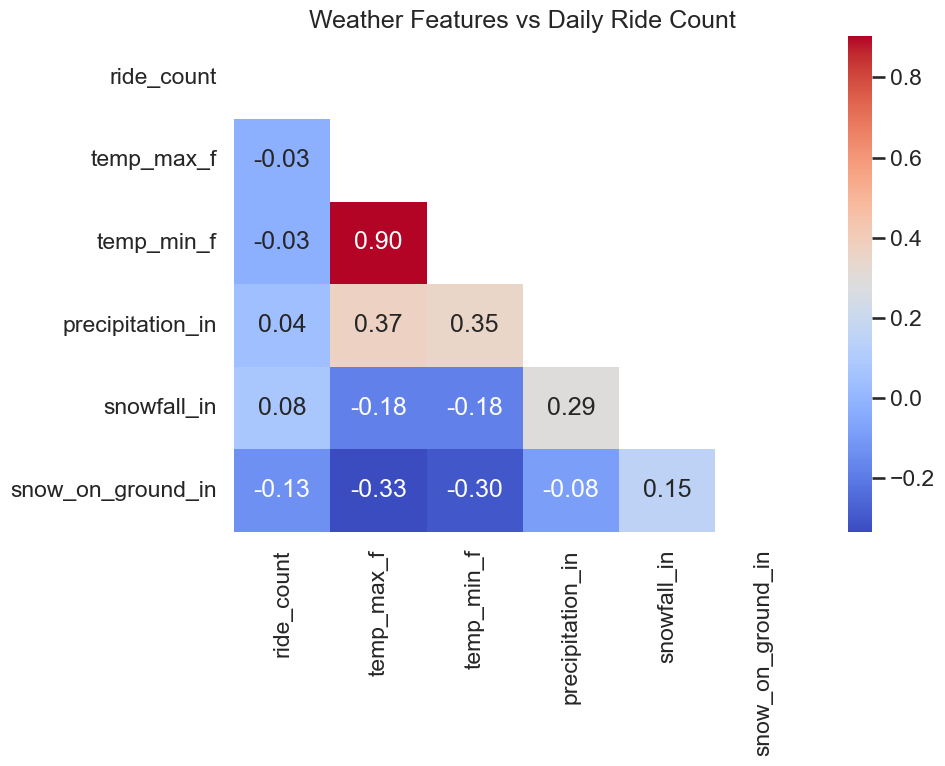

snowfall_in          0.075289
precipitation_in     0.042371
temp_min_f          -0.027438
temp_max_f          -0.029062
snow_on_ground_in   -0.133988
Name: ride_count, dtype: float64


In [50]:
# correlation matrix
analysis_cols = ['ride_count', 'temp_max_f', 'temp_min_f', 'precipitation_in', 'snowfall_in', 'snow_on_ground_in']
corr = daily[analysis_cols].corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

plt.subplots(figsize=(10, 8))
ax = sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Weather Features vs Daily Ride Count')
plt.tight_layout()
plt.show()

print(corr['ride_count'].drop('ride_count').sort_values(ascending=False))

Correlation values are very low, but `snow_on_ground_in` seems to be the most promising, showing a negative correlation (more snow on the ground = less demand)

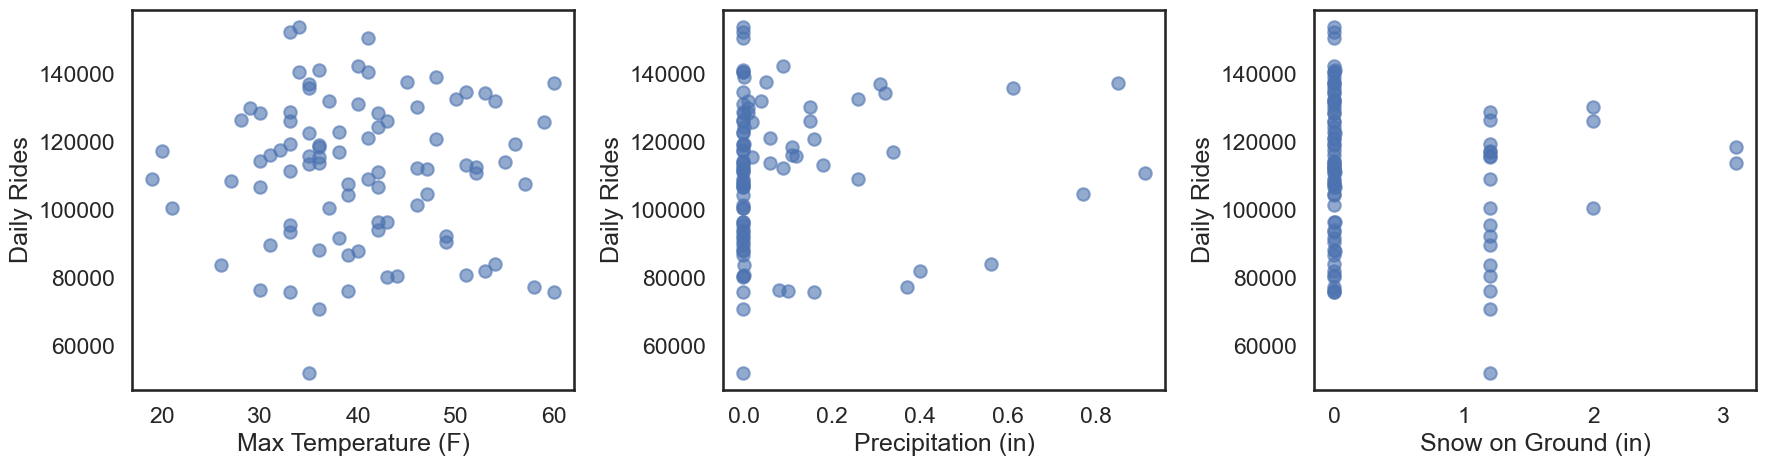

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(daily['temp_max_f'], daily['ride_count'], alpha=0.6)
axes[0].set_xlabel('Max Temperature (F)')
axes[0].set_ylabel('Daily Rides')

axes[1].scatter(daily['precipitation_in'], daily['ride_count'], alpha=0.6)
axes[1].set_xlabel('Precipitation (in)')
axes[1].set_ylabel('Daily Rides')

axes[2].scatter(daily['snow_on_ground_in'], daily['ride_count'], alpha=0.6)
axes[2].set_xlabel('Snow on Ground (in)')
axes[2].set_ylabel('Daily Rides')

plt.tight_layout()
plt.show()

Max Temperature looks as random as possible, so its no surprise it has an almost 0 Pearsons' correlation coefficient. Precipitation doesn't seem to show much promise either.

For `snow_on_ground` we unfortunately seem to only have 4 distinct values, however, it is faintly noticeable how the range of daily rides for those 4 values shift a bit downwards when there is more snow on the ground. 

### Seeing how each feature affects R-squared OLS result with ride_count

Runner up: snow_on_ground_in alone

In [52]:
model1 = smf.ols('ride_count ~ snow_on_ground_in', data=daily).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             ride_count   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.609
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.208
Time:                        01:52:19   Log-Likelihood:                -1022.9
No. Observations:                  90   AIC:                             2050.
Df Residuals:                      88   BIC:                             2055.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1.132e+05   2508.73

In [53]:
model2 = smf.ols('ride_count ~ temp_max_f + temp_min_f + precipitation_in + snowfall_in + snow_on_ground_in', data=daily).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             ride_count   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                 -0.025
Method:                 Least Squares   F-statistic:                    0.5673
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.725
Time:                        01:52:22   Log-Likelihood:                -1022.3
No. Observations:                  90   AIC:                             2057.
Df Residuals:                      84   BIC:                             2072.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1.208e+05   1.25e+0

In [54]:
# compare all models
models = {'snow_ground': model1, 'all features': model2}

comparison = pd.DataFrame({
    'R2': {n: m.rsquared for n, m in models.items()},
    'Adj_R2': {n: m.rsquared_adj for n, m in models.items()},
    'AIC': {n: m.aic for n, m in models.items()},
})
print(comparison.round(4))

                  R2  Adj_R2        AIC
snow_ground   0.0180  0.0068  2049.8735
all features  0.0327 -0.0249  2056.5150


From this we can conclude that: weather explains <4% of taxi demand variance across all OLS models. No coefficients seem significant.

**However** it is worth noting that we only had a few distinct snow_on_ground datapoints, and there is a possible confounding seasonal variance. The best comparison would be to look at the same exact day with snow vs without snow, but this isn't really possible. We have a reasonable proxy which are continuous days on months that snow. Nevertheless, it is worth mentioning this limitation

Conclusion: weather features do not meaningfully predict daily taxi demand.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent? 
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those? 
 - [ ] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [ ] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)? 
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)? 
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [ ] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory? X 
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)? X 
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [ ] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

Notes on ethical considerations:

The TLC trip data is collected without explicit rider consent, but does not have identifiable information about riders (A.1). Also it only covers TLC-regulated vehicles, leaving out public transit, biking, and personal cars (A.2). There are missing perspectives and dataset bias because we do not know anything about the riders (including reason for getting a taxi), and Manhattan is likely to skew the results due to being a densely populated area (C.1, C.2). Location features like pick-up and drop-off zones can also proxy for race and income due to NYC's geographical segregation (D.1, D.2).

As for location, the TLC's dataset divides NYC into 263 zones, which protects passenger privacy by avoiding exact GPS coordinates.

## Team Expectations 

Read over the [COGS108 Team Policies](https://github.com/COGS108/Projects/blob/master/COGS108_TeamPolicies.md) individually. Then, include your group's expectations of one another for successful completion of your COGS108 project below. Discuss and agree on what all of your expectations are. Discuss how your team will communicate throughout the quarter and consider how you will communicate respectfully should conflicts arise. By including each member's name above and by adding their name to the submission, you are indicating that you have read the COGS108 Team Policies, accept your team's expectations below, and have every intention to fulfill them. These expectations are for your team's use and benefit — they won't be graded for their details.

* Communicate using our Discord group chat.
* Reasonable to wait around 3-7 hours for a message to be replied to.
* We will meet once a week, on either Tuesday or Thursday, in person.
* Blunt but polite tone encouraged.
* Majority vote is how we will deal with things.
* Everyone will do a little bit of everything with tasks
* Keep track of everything using Google Sheets
* If someone is struggling, they should notify the group at least 72 hours after they have been struggling to find data information.

## Project Timeline Proposal


| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|-------------|--------------|--------------------------|--------------------|
| 2/4 | 8 pm | Reading and Discussing COGS 108 expectations. | Brainstorm topics for final project and decide on idea; discuss hypothesis; begin background research; submit project proposal. <br>Content covered in meeting:<br>- Decided on final project idea and research question: Out of specific features between temporal, spatial, and weather, which feature or combination of features has the most important effect on taxi-demands in New York City?<br>- Began brainstorming hypothesis.<br>- Background research was mostly completed during the meeting with data sets found, pending selection of ideal data sets. |
| 2/10 | 8 pm | Background research on topic; search for data sets. | Discuss ideal data sets; discuss wrangling and possible analytical approaches; assign roles for each group member to lead a specific part. <br>Content covered in meeting:<br>- Refined hypothesis to match and relate to our data sets.<br>- Discussed and found ideal data sets to use for the final project.<br>- Began wrangling data for ideal data sets. |
| 2/19 | 8 pm | Import and Wrangle Data; EDA | Review/Edit wrangling and EDA; discuss analysis plan. Decide on five pairs of features (one for each member) to dig deeper, including potential confounding variables and correlations with taxi demand, based on the correlation matrix of all variables. |
| 2/26 | 8 pm | Finalize wrangling/EDA; Begin Analysis | Discuss/edit analysis with focus on preliminary visualizations and model development/comparison based on feature selection from the previous meeting; complete project check-in. |
| 3/12 | 8 pm | Complete analysis; Draft results/conclusion/discussion | Discuss/edit full project with focus on finalizing plots, interpreting results, comparing model outcomes, and refining conclusions and final submission. Test selected features. |
| 3/20 | Before 11:59 pm | NA | Turn in Final Project and Group Project Surveys |
